In [93]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime as dt

import pandas as pd
import pandas_datareader.data as pdr
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import talib as ta

In [94]:
sys.path.append("/home/jovyan/notebook")
from Modules.get_market_data import GetMarketData
get_market_data = GetMarketData(Path('/home/jovyan/data'))

### 6.1 相場の強弱

[*********************100%***********************]  1 of 1 completed


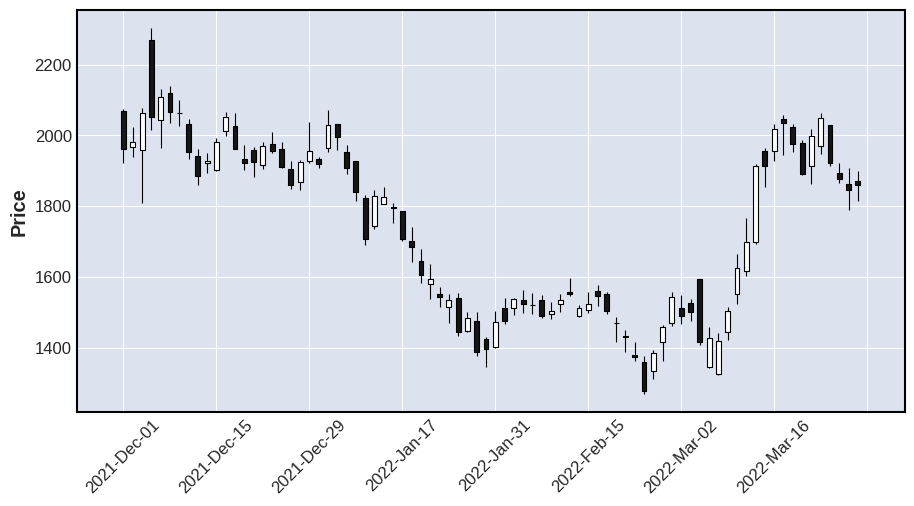

In [95]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 12, 1)

### ファーマフーズ (2929.T)
df = get_market_data.get_data_from_yfinance("2929.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']
rdf =[display_start_date, end_date]
mpf.plot(df[rdf[0]:rdf[1]], type='candle', figratio=(2,1))


[*********************100%***********************]  1 of 1 completed


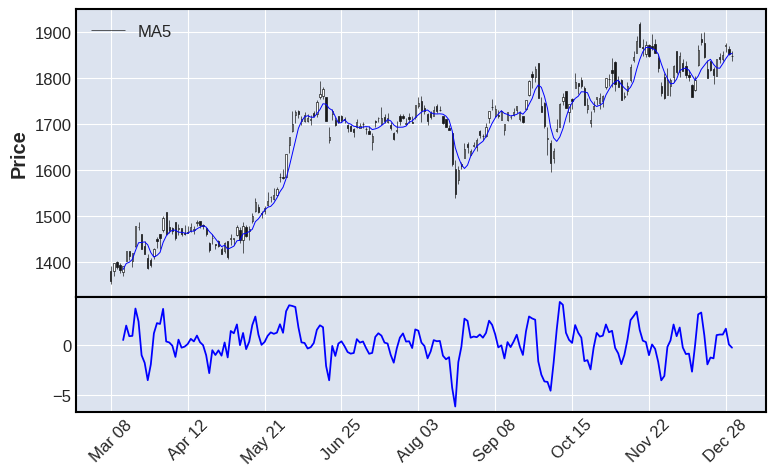

In [96]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2021, 12, 31)
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 1, 1)

### トヨタ自動車 (7203.T)
df = get_market_data.get_data_from_yfinance("7203.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 5日間移動平均線
df["ma5"] = df["Close"].rolling(window=5).mean()

# 乖離率
df['md5_deviation_rate'] = (close - df['ma5']) / df['ma5'] * 100

rdf =[display_start_date, end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(df['ma5'], panel=0, color='blue', width=0.7),
    # 乖離率 
    mpf.make_addplot(df['md5_deviation_rate'], panel=1, color='blue')
]

fig, axes = mpf.plot(df[rdf[0]:rdf[1]], type='candle', figratio=(5,3), addplot=apd, returnfig=True)
axes[0].legend(['MA5'])
axes[1].legend(['MD5 Deviation Rate'])
fig.show()

### 6.1.3 RSIの計算と表示

[*********************100%***********************]  1 of 1 completed


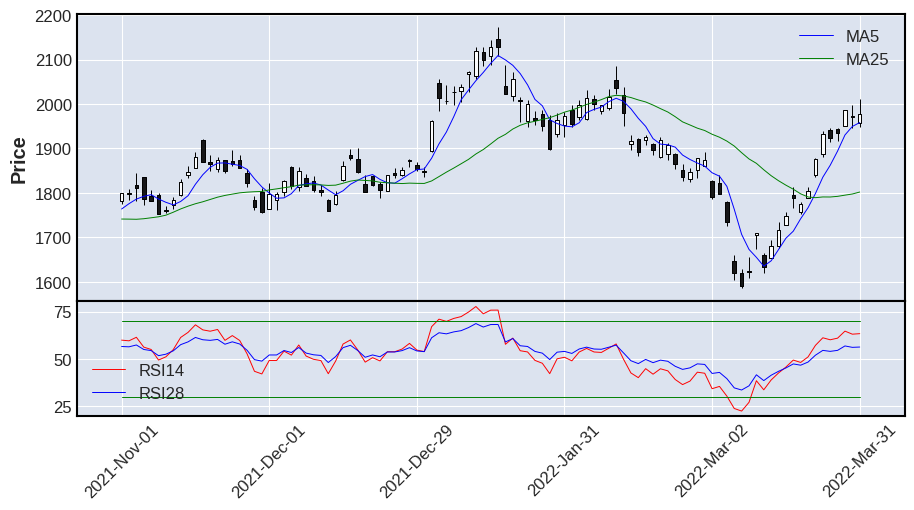

In [97]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 4, 1)

# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 11, 1)

# データ取得開始日(300日前の日付を計算)
start_date = display_start_date - dt.timedelta(days=300)

### トヨタ自動車 (7203.T)
df = get_market_data.get_data_from_yfinance("7203.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 移動平均線
df["ma5"], df["ma25"] = ta.SMA(close, timeperiod=5), ta.SMA(close, timeperiod=25)

# RSI
rsi14 = ta.RSI(close, timeperiod=14)
rsi28 = ta.RSI(close, timeperiod=28)
df['rsi14'], df['rsi28'] = rsi14, rsi28

# 補助線
df['70'] = [70 for _ in close]
df['30'] = [30 for _ in close]

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf['ma5'], color='blue', panel=0, width=0.7, label='MA5'),
    # 25日間移動平均線
    mpf.make_addplot(rdf['ma25'], color='green', panel=0, width=0.7, label='MA25'),
    # RSI14
    mpf.make_addplot(rdf['rsi14'], color='red', panel=1, width=0.7, label='RSI14'),
    # RSI28
    mpf.make_addplot(rdf['rsi28'], color='blue', panel=1, width=0.7, label='RSI28'),
    # 補助線70
    mpf.make_addplot(rdf['70'], panel=1, color='green', width=0.7),
    # 補助線30
    mpf.make_addplot(rdf['30'], panel=1, color='green', width=0.7)
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
axes[1].legend(['MA5', 'MA25'])
axes[1].legend(['RSI14', 'RSI28'])
fig.show()

### 6.1.4 ストキャスティクスの計算と表示

[*********************100%***********************]  1 of 1 completed


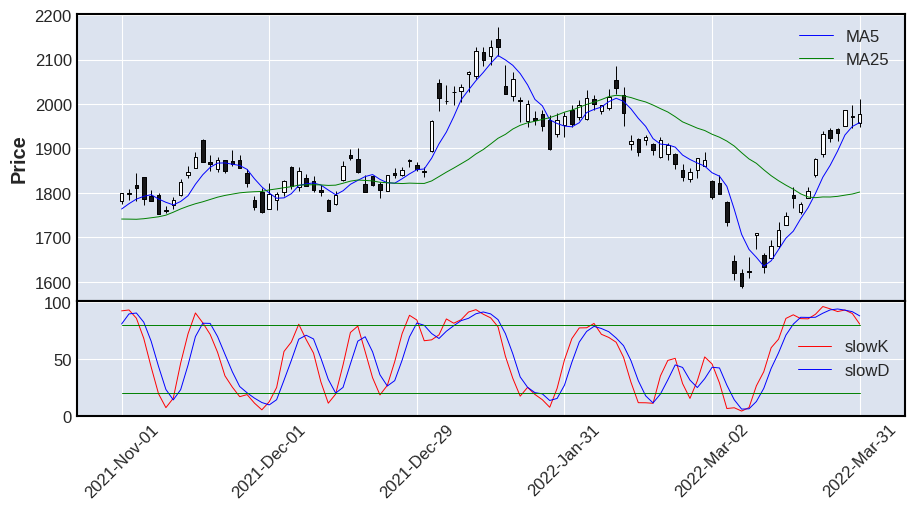

In [98]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 4, 1)

# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 11, 1)

# データ取得開始日(300日前の日付を計算)
start_date = display_start_date - dt.timedelta(days=300)

### トヨタ自動車 (7203.T)
df = get_market_data.get_data_from_yfinance("7203.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 移動平均線
df["ma5"], df["ma25"] = ta.SMA(close, timeperiod=5), ta.SMA(close, timeperiod=25)

# ストキャスティクス
slowK, slowD = ta.STOCH(df['High'], df['Low'], df['Close'],
                        fastk_period=5, slowk_period=3, slowk_matype=0,
                        slowd_period=3, slowd_matype=0)
df['slowK'], df['slowD'] = slowK, slowD

# 補助線
df['80'] = [80 for _ in close]
df['20'] = [20 for _ in close]

rdf = df[display_start_date:end_date]
apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf['ma5'], color='blue', panel=0, width=0.7, label='MA5'),
    # 25日間移動平均線
    mpf.make_addplot(rdf['ma25'], color='green', panel=0, width=0.7, label='MA25'),
    # ストキャスティクスslowK
    mpf.make_addplot(rdf['slowK'], color='red', panel=1, width=0.7, label='slowK'),
    # ストキャスティクスslowD
    mpf.make_addplot(rdf['slowD'], color='blue', panel=1, width=0.7, label='slowD'),
    # 補助線80
    mpf.make_addplot(rdf['80'], panel=1, color='green', width=0.7),
    # 補助線20
    mpf.make_addplot(rdf['20'], panel=1, color='green', width=0.7)
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
axes[1].legend(['MA5', 'MA25'])
axes[1].legend(['slowK', 'slowD'])
fig.show()

### 6.1.5 RSIのダイバージェンス

[*********************100%***********************]  1 of 1 completed


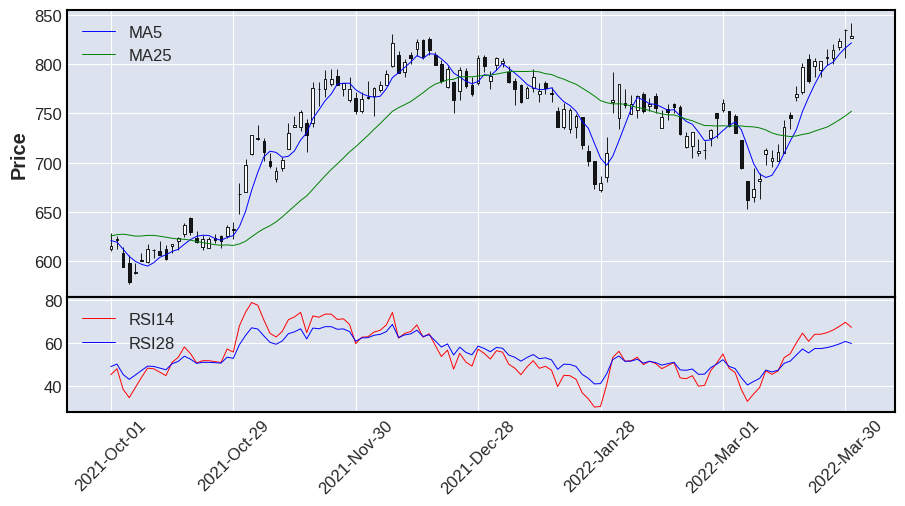

In [99]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 4, 1)

# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

# データ取得開始日(300日前の日付を計算)
start_date = display_start_date - dt.timedelta(days=300)

### ワコム (6727.T)
df = get_market_data.get_data_from_yfinance("6727.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 移動平均線
df["ma5"], df["ma25"] = ta.SMA(close, timeperiod=5), ta.SMA(close, timeperiod=25)

# RSI
rsi14 = ta.RSI(close, timeperiod=14)
rsi28 = ta.RSI(close, timeperiod=28)
df['rsi14'], df['rsi28'] = rsi14, rsi28

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf['ma5'], color='blue', panel=0, width=0.7, label='MA5'),
    # 25日間移動平均線
    mpf.make_addplot(rdf['ma25'], color='green', panel=0, width=0.7, label='MA25'),
    # RSI14
    mpf.make_addplot(rdf['rsi14'], color='red', panel=1, width=0.7, label='RSI14'),
    # RSI28
    mpf.make_addplot(rdf['rsi28'], color='blue', panel=1, width=0.7, label='RSI28'),
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
axes[1].legend(['MA5', 'MA25'])
axes[1].legend(['RSI14', 'RSI28'])
fig.show()

## 6.2 複数の指標を可視化する

### 6.2.1 RSIとストキャスティクスを同時に表示

[*********************100%***********************]  1 of 1 completed


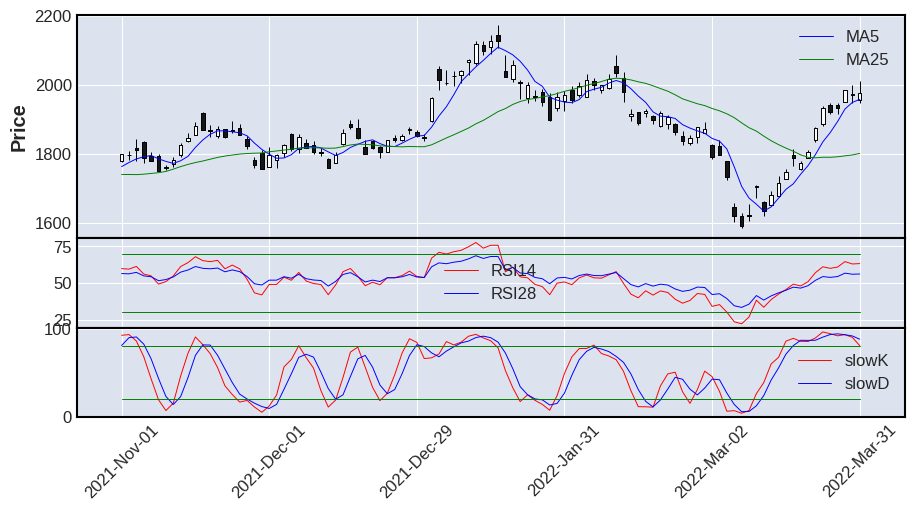

In [100]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 4, 1)

# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 11, 1)

# データ取得開始日(300日前の日付を計算)
start_date = display_start_date - dt.timedelta(days=300)

### トヨタ自動車 (7203.T)
df = get_market_data.get_data_from_yfinance("7203.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 移動平均線
df["ma5"], df["ma25"] = ta.SMA(close, timeperiod=5), ta.SMA(close, timeperiod=25)

# RSI
rsi14 = ta.RSI(close, timeperiod=14)
rsi28 = ta.RSI(close, timeperiod=28)
df['rsi14'], df['rsi28'] = rsi14, rsi28

# 補助線
df['70'] = [70 for _ in close]
df['30'] = [30 for _ in close]

# ストキャスティクス
slowK, slowD = ta.STOCH(df['High'], df['Low'], df['Close'],
                        fastk_period=5, slowk_period=3, 
                        slowk_matype=0, slowd_period=3,
                        slowd_matype=0)
df['slowK'], df['slowD'] = slowK, slowD

df['80'] = [80 for _ in close]
df['20'] = [20 for _ in close]

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf['ma5'], color='blue', panel=0, width=0.7, label='MA5'),
    # 25日間移動平均線
    mpf.make_addplot(rdf['ma25'], color='green', panel=0, width=0.7, label='MA25'),
    # RSI14
    mpf.make_addplot(rdf['rsi14'], color='red', panel=1, width=0.7, label='RSI14'),
    # RSI28
    mpf.make_addplot(rdf['rsi28'], color='blue', panel=1, width=0.7, label='RSI28'),
    # 補助線70
    mpf.make_addplot(rdf['70'], panel=1, color='green', width=0.7),
    # 補助線30
    mpf.make_addplot(rdf['30'], panel=1, color='green', width=0.7),
    # ストキャスティクスslowK
    mpf.make_addplot(rdf['slowK'], color='red', panel=2, width=0.7, label='slowK'),
    # ストキャスティクスslowD
    mpf.make_addplot(rdf['slowD'], color='blue', panel=2, width=0.7, label='slowD'),
    # 補助線80
    mpf.make_addplot(rdf['80'], panel=2, color='green', width=0.7),
    # 補助線20
    mpf.make_addplot(rdf['20'], panel=2, color='green', width=0.7),
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
axes[1].legend(['MA5', 'MA25'])
axes[2].legend(['RSI14', 'RSI28'])
axes[4].legend(['slowK', 'slowD'])
fig.show()

### 6.2.2 相場の強弱とトレンドの転換

[*********************100%***********************]  1 of 1 completed


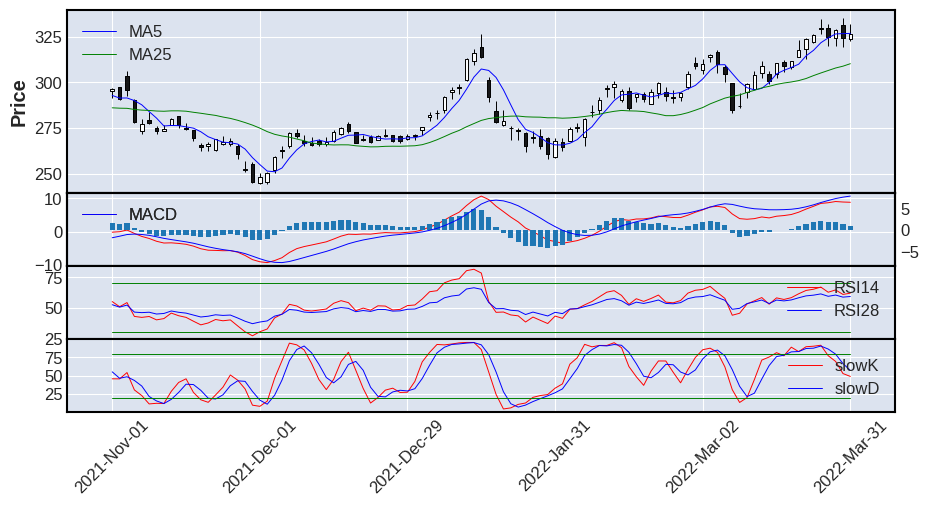

In [101]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 4, 1)

# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 11, 1)

# データ取得開始日(300日前の日付を計算)
start_date = display_start_date - dt.timedelta(days=300)

### 日本製鉄 (5401.T)
df = get_market_data.get_data_from_yfinance("5401.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 移動平均線
df["ma5"], df["ma25"] = ta.SMA(close, timeperiod=5), ta.SMA(close, timeperiod=25)

# MACD  シグナル, ヒストグラム
macd, macdsignal, hist = ta.MACD(close, fastperiod=12, slowperiod=26,
                                 signalperiod=9)
df['macd'] = macd
df['macd_signal'] = macdsignal
df['hist'] = hist

# RSI
rsi14 = ta.RSI(close, timeperiod=14)
rsi28 = ta.RSI(close, timeperiod=28)
df['rsi14'], df['rsi28'] = rsi14, rsi28

# 補助線
df['70'] = [70 for _ in close]
df['30'] = [30 for _ in close]

# ストキャスティクス
slowK, slowD = ta.STOCH(df['High'], df['Low'], df['Close'],
                        fastk_period=5, slowk_period=3, 
                        slowk_matype=0, slowd_period=3,
                        slowd_matype=0)
df['slowK'], df['slowD'] = slowK, slowD
df['80'] = [80 for _ in close]
df['20'] = [20 for _ in close]

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf['ma5'], color='blue', panel=0, width=0.7, label='MA5'),
    # 25日間移動平均線
    mpf.make_addplot(rdf['ma25'], color='green', panel=0, width=0.7, label='MA25'),
    # MACD
    mpf.make_addplot(rdf['macd'], color='red', panel=1, width=0.7, label='MACD'),
    # シグナル
    mpf.make_addplot(rdf['macd_signal'], color='blue', panel=1, width=0.7, label='SIGNAL'),
    # ヒストグラム
    mpf.make_addplot(rdf['hist'], type='bar', panel=1, width=0.7),
    # RSI14
    mpf.make_addplot(rdf['rsi14'], color='red', panel=2, width=0.7, label='RSI14'),
    # RSI28
    mpf.make_addplot(rdf['rsi28'], color='blue', panel=2, width=0.7, label='RSI28'),
    # 補助線70
    mpf.make_addplot(rdf['70'], panel=2, color='green', width=0.7),
    # 補助線30
    mpf.make_addplot(rdf['30'], panel=2, color='green', width=0.7),
    # ストキャスティクスslowK
    mpf.make_addplot(rdf['slowK'], color='red', panel=3, width=0.7, label='slowK'),
    # ストキャスティクスslowD
    mpf.make_addplot(rdf['slowD'], color='blue', panel=3, width=0.7, label='slowD'),
    # 補助線80
    mpf.make_addplot(rdf['80'], panel=3, color='green', width=0.7),
    # 補助線20
    mpf.make_addplot(rdf['20'], panel=3, color='green', width=0.7),
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(2,1), addplot=apd, returnfig=True)
axes[1].legend(['MA5', 'MA25'])
axes[3].legend(['MACD'])
axes[4].legend(['RSI14', 'RSI28'])
axes[6].legend(['slowK', 'slowD'])
fig.show()

### 6.2.3 株価の変動範囲を表示する

[*********************100%***********************]  1 of 1 completed


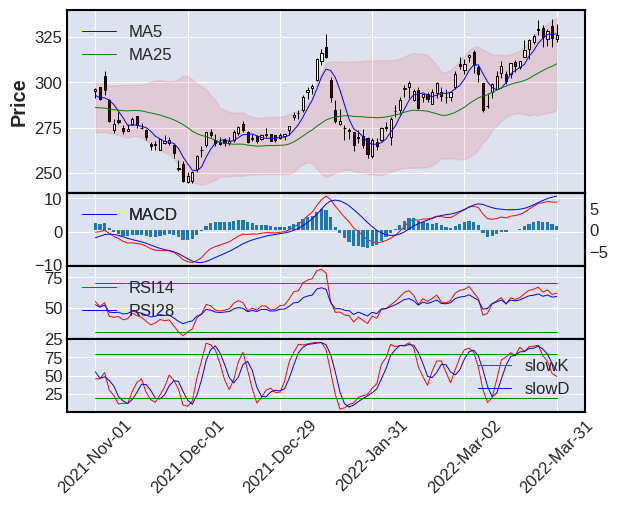

In [102]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 4, 1)

# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 11, 1)

# データ取得開始日(300日前の日付を計算)
start_date = display_start_date - dt.timedelta(days=300)

### 日本製鉄 (5401.T)
df = get_market_data.get_data_from_yfinance("5401.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df['Close']

# 移動平均線
df["ma5"], df["ma25"] = ta.SMA(close, timeperiod=5), ta.SMA(close, timeperiod=25)

# MACD  シグナル, ヒストグラム
macd, macdsignal, hist = ta.MACD(close, fastperiod=12, slowperiod=26,
                                 signalperiod=9)
df['macd'] = macd
df['macd_signal'] = macdsignal
df['hist'] = hist

# RSI
rsi14 = ta.RSI(close, timeperiod=14)
rsi28 = ta.RSI(close, timeperiod=28)
df['rsi14'], df['rsi28'] = rsi14, rsi28

# 補助線
df['70'] = [70 for _ in close]
df['30'] = [30 for _ in close]

# ストキャスティクス
slowK, slowD = ta.STOCH(df['High'], df['Low'], df['Close'],
                        fastk_period=5, slowk_period=3, 
                        slowk_matype=0, slowd_period=3,
                        slowd_matype=0)
df['slowK'], df['slowD'] = slowK, slowD
df['80'] = [80 for _ in close]
df['20'] = [20 for _ in close]

# ボリンジャーバンド±2σ
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2,
                                          nbdevdn=2, matype=ta.MA_Type.SMA)

rdf = df[display_start_date:end_date]

apd = [
    # 5日間移動平均線
    mpf.make_addplot(rdf['ma5'], color='blue', panel=0, width=0.7, label='MA5'),
    # 25日間移動平均線
    mpf.make_addplot(rdf['ma25'], color='green', panel=0, width=0.7, label='MA25'),
    # MACD
    mpf.make_addplot(rdf['macd'], color='red', panel=1, width=0.7, label='MACD'),
    # シグナル
    mpf.make_addplot(rdf['macd_signal'], color='blue', panel=1, width=0.7, label='SIGNAL'),
    # ヒストグラム
    mpf.make_addplot(rdf['hist'], type='bar', panel=1, width=0.7),
    # RSI14
    mpf.make_addplot(rdf['rsi14'], color='red', panel=2, width=0.7, label='RSI14'),
    # RSI28
    mpf.make_addplot(rdf['rsi28'], color='blue', panel=2, width=0.7, label='RSI28'),
    # 補助線70
    mpf.make_addplot(rdf['70'], panel=2, color='green', width=0.7),
    # 補助線30
    mpf.make_addplot(rdf['30'], panel=2, color='green', width=0.7),
    # ストキャスティクスslowK
    mpf.make_addplot(rdf['slowK'], color='red', panel=3, width=0.7, label='slowK'),
    # ストキャスティクスslowD
    mpf.make_addplot(rdf['slowD'], color='blue', panel=3, width=0.7, label='slowD'),
    # 補助線80
    mpf.make_addplot(rdf['80'], panel=3, color='green', width=0.7),
    # 補助線20
    mpf.make_addplot(rdf['20'], panel=3, color='green', width=0.7),
]

fig, axes = mpf.plot(rdf, type='candle', figratio=(5,4), 
                    addplot=apd, returnfig=True,
                    fill_between={"y1": rdf['lower2'].values,
                                  "y2": rdf['upper2'].values,
                                  "color": 'red', "alpha": 0.1})
axes[1].legend(['MA5', 'MA25'])
axes[3].legend(['MACD'])
axes[4].legend(['RSI14', 'RSI28'])
axes[6].legend(['slowK', 'slowD'])
fig.show()